In [1]:
import pandas as pd 
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA   




In [4]:
df  = pd.read_csv('../data/customer_segmentation.csv')

## display all the columns in the dataset
pd.set_option('display.max_columns', None)
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [5]:
df.shape


(2240, 29)

In [ ]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [ ]:
df.dropna(inplace=True)  ## drop null values
df.shape


(2216, 29)

In [ ]:
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
df['Education'].value_counts()



Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [ ]:
df['Marital_Status'].value_counts()


Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [ ]:
# Clean the marital status column by replacing 'Alone' 'abstract' and 'YOLO' with 'Single'
df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')
df['Marital_Status'].value_counts()


Marital_Status
Married     857
Together    573
Single      478
Divorced    232
Widow        76
Name: count, dtype: int64

In [ ]:
df["Dt_Customer"].value_counts()


Dt_Customer
31-08-2012    12
14-02-2013    11
12-05-2014    11
12-09-2012    11
20-08-2013    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 662, dtype: int64

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")  # convert to datetime format
df["Customer_Since"] = (pd.to_datetime("today") - df["Dt_Customer"]).dt.days  # calculate years how long the customer has been with the company
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,4957
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4407
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4606
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4433
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4455


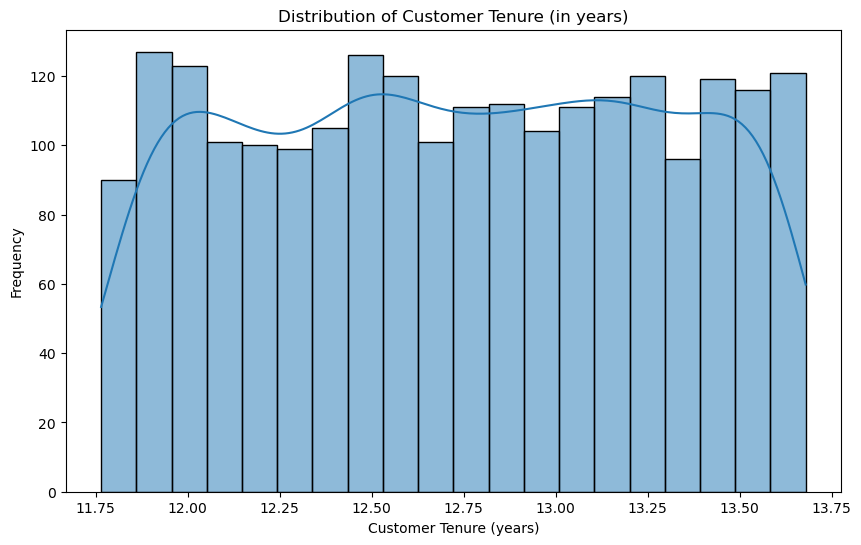

In [ ]:
## draw graph to show the distribution of how long customers have been with the company

plt.figure(figsize=(10,6))
sns.histplot(df['Customer_Since']/365, bins=20, kde=True)
plt.title('Distribution of Customer Tenure (in years)') 
plt.xlabel('Customer Tenure (years)')
plt.ylabel('Frequency')
plt.show()



In [ ]:
df["Age"] = (pd.to_datetime("today") - pd.to_datetime(df["Year_Birth"], format="%Y")).dt.days // 365
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,4957,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4407,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4606,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4433,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4455,45


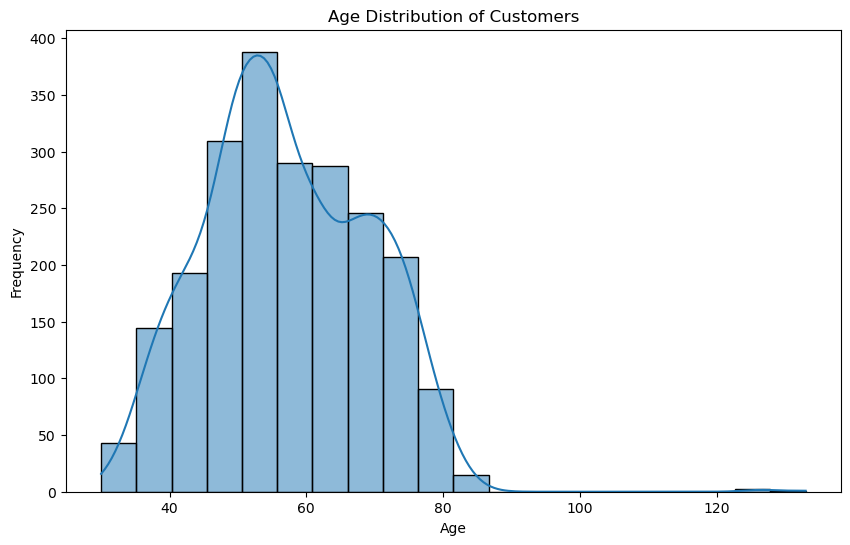

In [ ]:
## Age distribution graph
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [ ]:
df["Age"].describe()


count    2216.000000
mean       57.179603
std        11.985554
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

In [ ]:
df[df["Age"]>100]  ## check for outliers in age column


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,3,11,0,4570,126
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,3,11,0,4337,133
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,3,11,0,4570,127


In [ ]:
df = df[df["Age"]<100]   ## remove outliers in age column


In [ ]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,4957,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4407,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4606,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4433,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4455,45


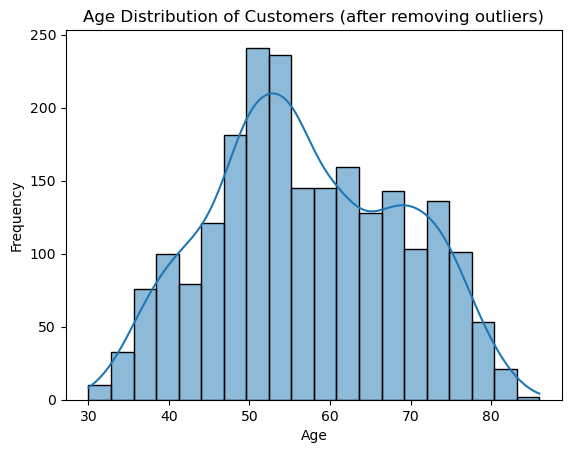

In [ ]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution of Customers (after removing outliers)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()    


In [ ]:
df["total_children"] = df["Kidhome"] + df["Teenhome"]  ## create a new column for total number of children in the household
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age,total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,4957,69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4407,72,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4606,61,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4433,42,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4455,45,1


In [ ]:
## Total amount spent by each customer
df["total_amount_spent"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df.head()



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age,total_children,total_amount_spent
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,4957,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4407,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4606,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4433,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4455,45,1,422


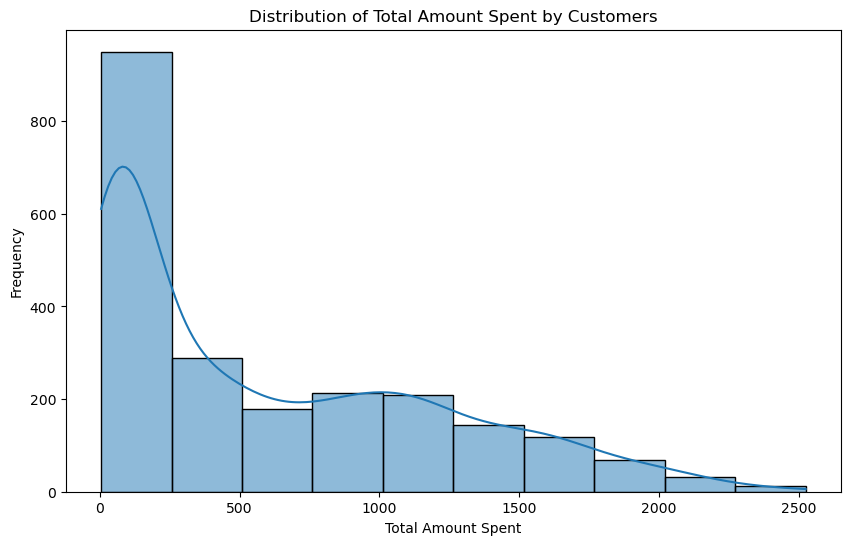

In [ ]:
## visualize the total amount spent by customers
plt.figure(figsize=(10,6))
sns.histplot(df['total_amount_spent'], bins=10, kde=True)
plt.title('Distribution of Total Amount Spent by Customers')
plt.xlabel('Total Amount Spent')
plt.ylabel('Frequency')
plt.show()



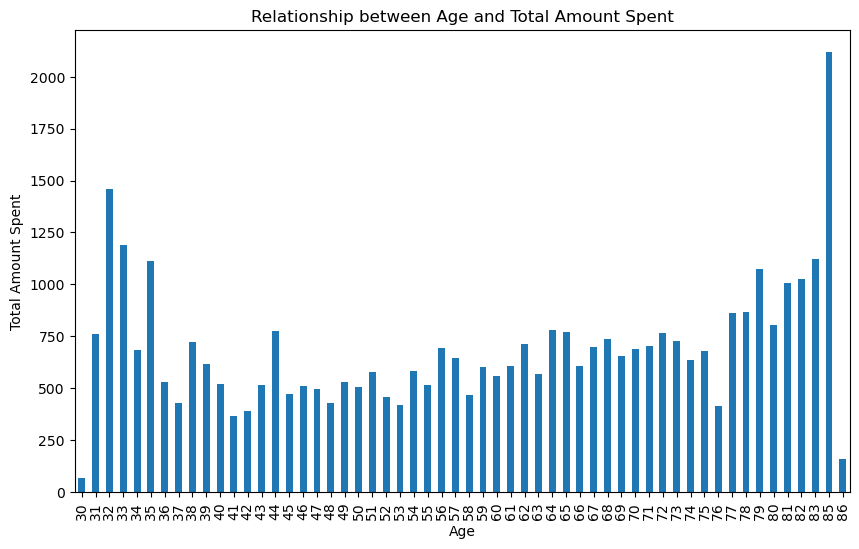

In [ ]:
# Visualize the relationship between age and total amount spent
plt.figure(figsize=(10,6))
df.groupby('Age')['total_amount_spent'].mean().plot(kind='bar')
plt.title('Relationship between Age and Total Amount Spent')    
plt.xlabel('Age')
plt.ylabel('Total Amount Spent')
plt.show()


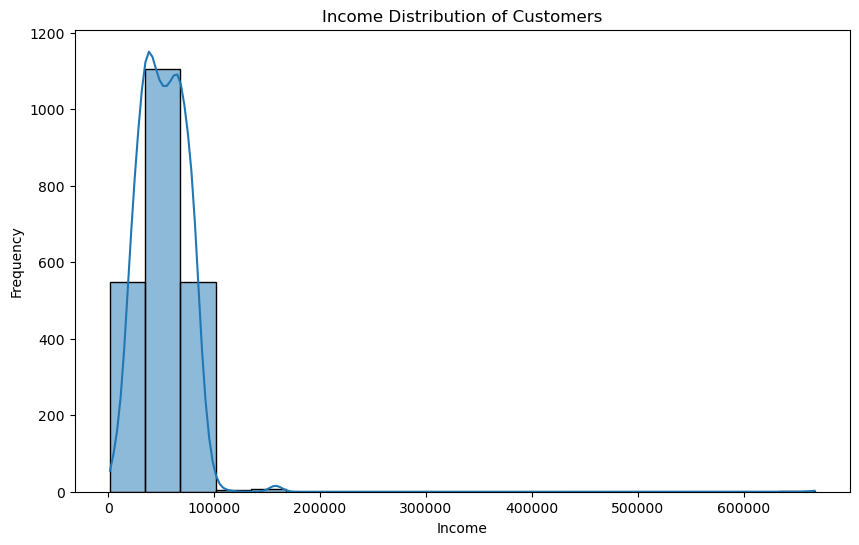

In [ ]:
## Visualize the Income distribution of customers
plt.figure(figsize=(10,6))  
sns.histplot(df['Income'], bins=20, kde=True)
plt.title('Income Distribution of Customers')   
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()



In [ ]:
df[df["Income"]>150000]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age,total_children,total_amount_spent
164,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,3,11,0,4414,53,1,1608
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0,4685,50,2,107
655,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0,4436,51,0,6
687,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,3,11,0,4988,44,0,1717
1300,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,3,11,0,4684,55,1,59
1653,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,3,11,0,4720,49,0,1730
2132,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0,4598,77,0,8
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0,4686,49,1,62


In [ ]:
df = df.drop(2233)  ## remove the outlier in income column


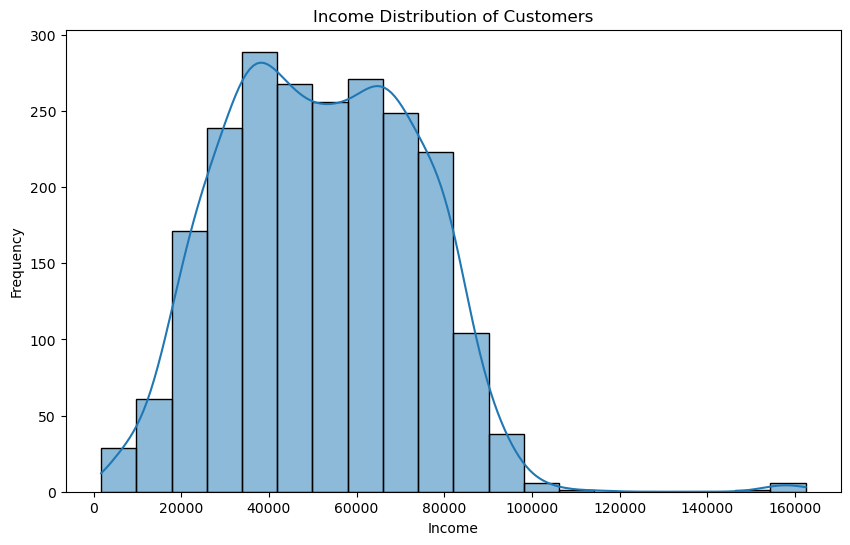

In [ ]:
## Visualize the Income distribution of customers
plt.figure(figsize=(10,6))  
sns.histplot(df['Income'], bins=20, kde=True)
plt.title('Income Distribution of Customers')   
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


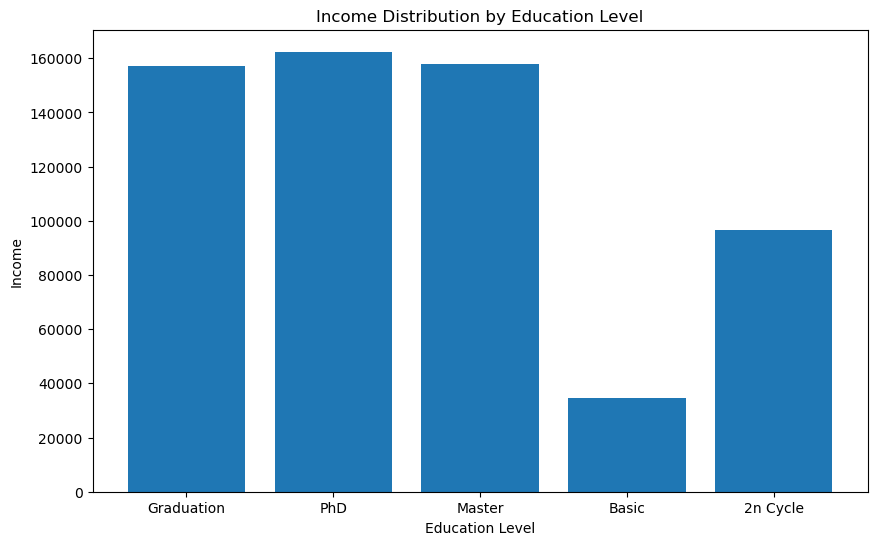

In [ ]:
## Visualize the income distribution by education level
plt.figure(figsize=(10,6))
plt.bar(df['Education'], df['Income'])
plt.title('Income Distribution by Education Level') 
plt.xlabel('Education Level')
plt.ylabel('Income')
plt.show()


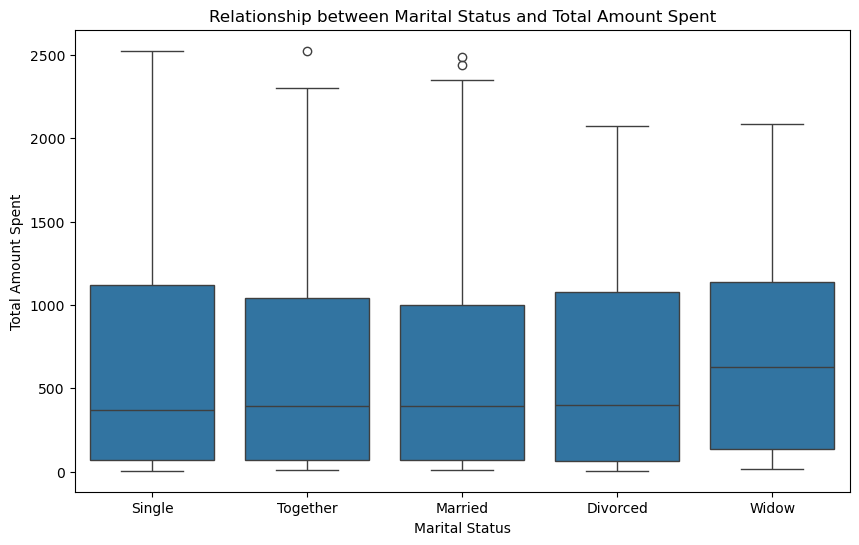

In [ ]:
# Visualize the relationship between marital status and total amount spent

plt.figure(figsize=(10,6))
sns.boxplot(x='Marital_Status', y='total_amount_spent', data=df)    
plt.title('Relationship between Marital Status and Total Amount Spent')
plt.xlabel('Marital Status')
plt.ylabel('Total Amount Spent')
plt.show()



In [ ]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Customer_Since', 'Age', 'total_children', 'total_amount_spent'],
      dtype='object')

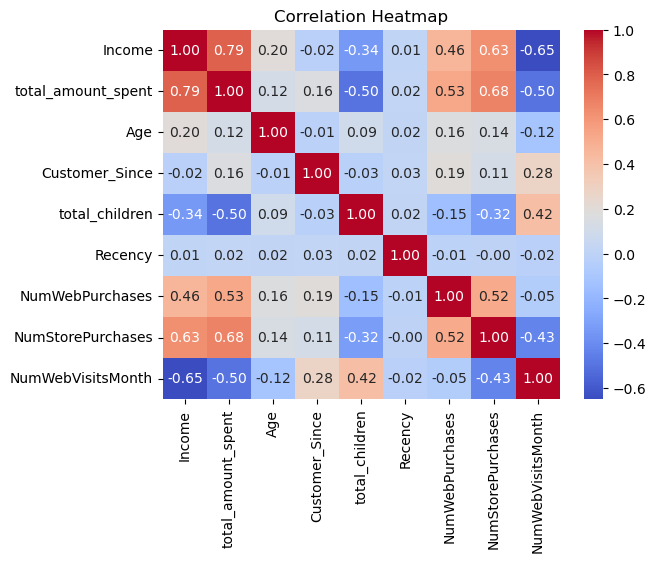

In [ ]:
corr = df[["Income", "total_amount_spent", "Age", "Customer_Since", "total_children", "Recency", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth"]]
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
## Pivot table to show average total amount spent by education level and marital status
pivot_table = df.pivot_table(values='total_amount_spent', index='Education', columns='Marital_Status', aggfunc='mean')
print(pivot_table)


Marital_Status    Divorced     Married      Single    Together       Widow
Education                                                                 
2n Cycle        677.818182  427.725000  568.685714  472.839286  677.200000
Basic            29.000000  122.850000   57.722222   56.428571  102.000000
Graduation      616.411765  595.752914  615.919355  663.242958  677.142857
Master          551.297297  566.666667  750.051948  560.980392  817.545455
PhD             632.865385  718.063158  616.838384  644.382609  797.666667


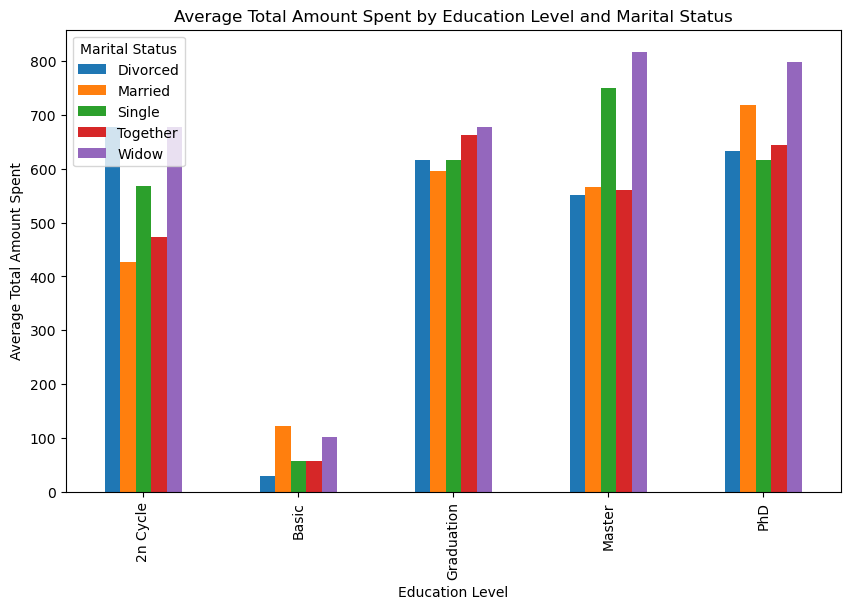

In [ ]:
# Visualize the pivot table using bar plot
pivot_table.plot(kind='bar', figsize=(10,6))    
plt.title('Average Total Amount Spent by Education Level and Marital Status')
plt.xlabel('Education Level')
plt.ylabel('Average Total Amount Spent')
plt.legend(title='Marital Status')  
plt.show()  


* This pivot table helps identify high-value customer segments based on education and marital status. 
* I observed that customers with higher education levels such as Master and PhD have significantly higher average values, especially widowed and single individuals.
* This insight can be used for targeted marketing and customer segmentation strategies.”

In [ ]:
group_1 = df.groupby('Education')['total_amount_spent'].mean().sort_values(ascending=False)
print(group_1)


Education
PhD           674.283333
Graduation    622.188341
Master        609.767123
2n Cycle      499.489899
Basic          81.796296
Name: total_amount_spent, dtype: float64


In [ ]:
# Accept any of AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5

df['Accept_any_cmp'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)



In [ ]:
df["Accept_any_cmp"].unique()


array([0, 1, 2, 3, 4])

In [ ]:
df['Accept_any_cmp'] = df['Accept_any_cmp'].apply(lambda x: 1 if x > 0 else 0)  ## convert to binary variable (1 if accepted any campaign, 0 if not)
df["Accept_any_cmp"].value_counts()


Accept_any_cmp
0    1754
1     458
Name: count, dtype: int64

In [ ]:
group_2 = df.groupby('Marital_Status')['Accept_any_cmp'].mean().sort_values(ascending=False)
print(group_2)


Marital_Status
Widow       0.236842
Married     0.211202
Single      0.207547
Together    0.199650
Divorced    0.199134
Name: Accept_any_cmp, dtype: float64


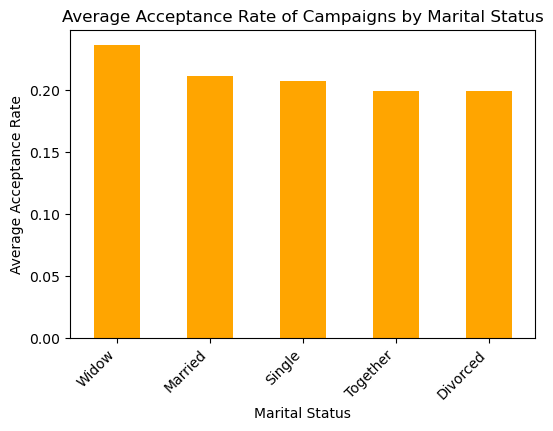

In [ ]:
group_2.plot(kind='bar', color = 'orange', figsize=(6,4))
plt.title('Average Acceptance Rate of Campaigns by Marital Status')
plt.xticks(rotation=45, ha='right')  ## rotate x-axis labels to horizontal
plt.xlabel('Marital Status')
plt.ylabel('Average Acceptance Rate')
plt.show()


In [ ]:
## Average income by age group
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
                        
group_3 = df.groupby('Age_Group')['Income'].mean().sort_values(ascending=False)
print(group_3)


Age_Group
Senior         54193.052493
Middle-aged    47114.804665
Young          10960.500000
Name: Income, dtype: float64


C:\Users\rpuli\AppData\Local\Temp\ipykernel_32424\3218459612.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



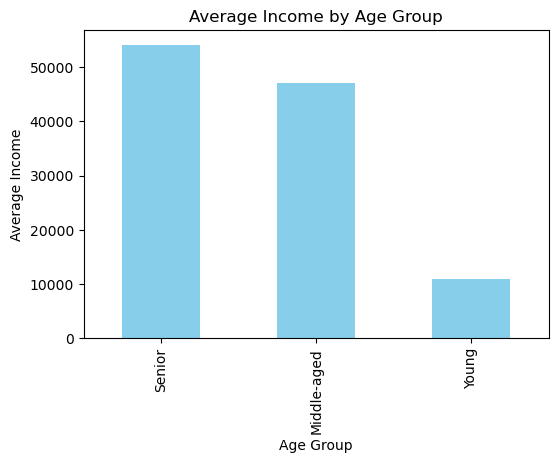

In [ ]:
group_3.plot(kind='bar', color = 'skyblue', figsize=(6,4))
plt.title('Average Income by Age Group')
plt.xlabel('Age Group') 
plt.ylabel('Average Income')
plt.show()


In [ ]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Customer_Since', 'Age', 'total_children', 'total_amount_spent',
       'Accept_any_cmp', 'Age_Group'],
      dtype='object')

In [ ]:
# Let's select 5 or 6 features that are most relevant for customer segmentation and create a new dataframe with those features

selected_features = df[['Age', 'Income', 'total_amount_spent', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']]
X = selected_features.copy()
X.head()


,Age,Income,total_amount_spent,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94


In [ ]:
## Scaling the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Model 1

In [377]:
# K-Means Clustering
from sklearn.cluster import KMeans  

wcss = []  ## within-cluster sum of squares
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


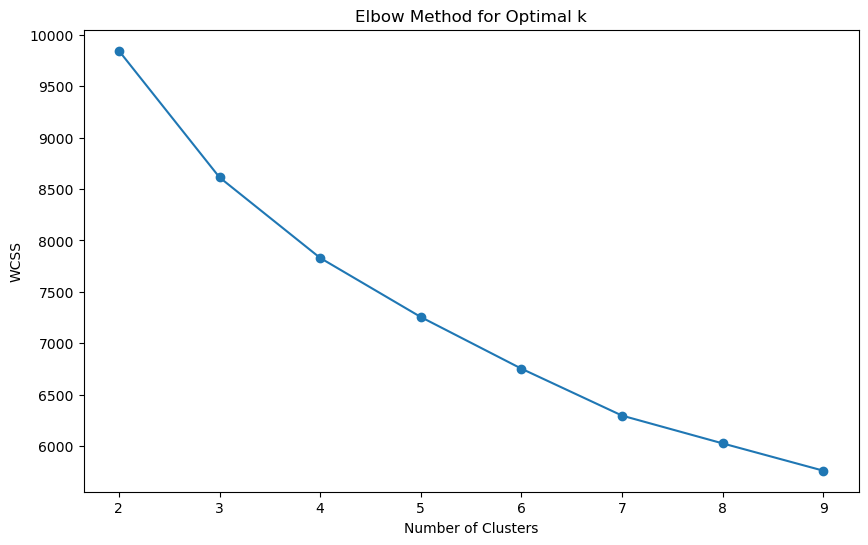

In [378]:
plt.figure(figsize=(10,6))
plt.plot(range(2,10), wcss, marker='o')
plt.title('Elbow Method for Optimal k') 
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



In [387]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster'].value_counts()


cluster
3    510
2    487
5    314
4    303
1    301
0    297
Name: count, dtype: int64

In [388]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Since,Age,total_children,total_amount_spent,Accept_any_cmp,Age_Group,cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,4957,69,0,1617,0,Senior,4
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,4407,72,2,27,0,Senior,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,4606,61,0,776,0,Senior,4
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,4433,42,1,53,0,Middle-aged,3
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,4455,45,1,422,0,Middle-aged,2


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['pca_1'] = pca_data[:, 0]
df['pca_2'] = pca_data[:, 1]   


In [395]:
pca_data


array([[ 1.12480086, -0.50853969],
       [-1.31691937,  0.15477992],
       [ 1.94262293, -1.06262695],
       ...,
       [ 1.15497524,  1.30477736],
       [ 1.94481032, -1.22348431],
       [-0.80599452, -0.37604285]])

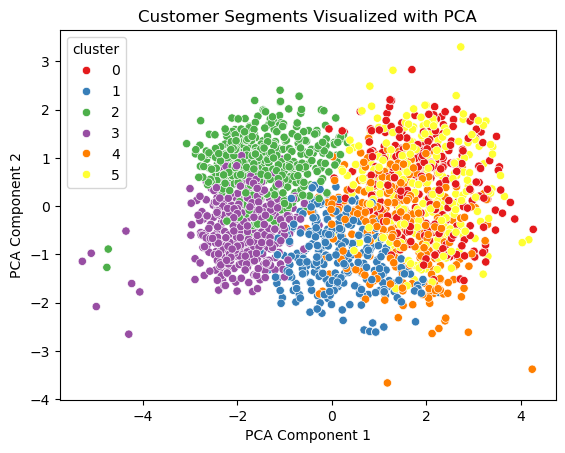

In [396]:
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', data=df, palette='Set1')
plt.title('Customer Segments Visualized with PCA')  
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [398]:
from sklearn.metrics import silhouette_score

silhouette_score= silhouette_score(X_scaled, df['cluster'])
print(f'Silhouette Score: {silhouette_score:.2f}')


Silhouette Score: 0.19


In [399]:
cluster_summary = df.groupby('cluster')[selected_features.columns].mean() 
print(cluster_summary)


               Age        Income  total_amount_spent  NumWebPurchases  \
cluster                                                                 
0        70.242424  74147.760943         1189.922559         4.478114   
1        63.697674  53126.265781          532.279070         5.521595   
2        56.320329  36538.106776          128.848049         2.357290   
3        51.329412  31263.870588           79.329412         1.858824   
4        58.950495  62532.316832         1025.415842         8.297030   
5        47.044586  77178.579618         1324.031847         4.589172   

         NumStorePurchases  NumWebVisitsMonth    Recency  
cluster                                                   
0                 8.326599           2.417508  54.367003  
1                 6.162791           6.192691  25.418605  
2                 3.445585           6.388090  77.135524  
3                 2.970588           6.666667  27.700000  
4                 8.686469           6.161716  60.026403  
5 

Cluster 0

Older, wealthy customers who spend a lot, mostly in-store, visit the website rarely, and haven’t purchased very recently.

Cluster 1

Older, medium-income customers who are engaged both online and offline, spend moderately, and purchased recently.

Cluster 2

Middle-aged, low-income customers with very low spending, low purchases, and inactive for a long time.

Cluster 3

Slightly younger, low-income customers who browse online frequently but rarely purchase, with moderate recency.

Cluster 4

Middle-aged, high-income customers with high spending, active across web and store, moderate recency.

Cluster 5

Young, very high-income customers with the highest spending, active in-store, low browsing, and moderate recency.


In [391]:
import pickle
with open('kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
